In [1]:
import torch

In [2]:
### Select device (GPU)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
print('Selected device:', device)

Selected device: cuda


In [3]:
with open('../data-sets/tiny_shakespeare.txt', 'r', encoding='utf-8') as f:
    text = f.read()

dataset = text

import random
print('Random line:', random.choice(dataset.split('\n')))
print('Size of dataset:', len(dataset.split('\n')), 'lines')

Random line: LUCIO:
Size of dataset: 40001 lines


In [4]:
unique_chars = sorted(set(dataset))

print(unique_chars)

char_to_num = {char: num for num, char in enumerate(unique_chars)}
num_to_char = {num: char for char, num in char_to_num.items()}

vocab_size = len(unique_chars) # Vocabulary size |V|
print('Number of unique chars:', vocab_size)

['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Number of unique chars: 65


In [5]:
import torch
import random
import torch.nn.functional as F

### Create data set ###
seq_len = 75

def build_dataset(data):
    X, Y = [], []
    
    context = [0] * seq_len
    
    for ch in data:
        X.append(context)
        ix = char_to_num[ch]
        context = context[1:] + [ix]
        Y.append(context)

    X = torch.tensor(X)
    Y = torch.tensor(Y)

    return X, Y

split = int(0.8 * len(dataset))

Xtr, Ytr = build_dataset(dataset[:split])
Xte, Yte = build_dataset(dataset[split:])

ix = random.randint(0, len(Xtr) - 1) 
print('Training data shape:', Xtr.shape, '=>', Ytr.shape)
print('Random example:', Xtr[ix].shape, '=>', Ytr[ix].shape)
print('Amount of train examples:', len(Xtr))

Training data shape: torch.Size([892315, 75]) => torch.Size([892315, 75])
Random example: torch.Size([75]) => torch.Size([75])
Amount of train examples: 892315


In [6]:
import torch.nn as nn

emb_dim = 60
hidden_size = 200
num_layers = 3

class RNN(nn.Module):
    def __init__(self, hidden_size, num_layers=1):
        super(RNN, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embeddings = nn.Embedding(vocab_size, emb_dim)
        self.rnn        = nn.RNN(emb_dim, hidden_size, num_layers, batch_first=True)
        self.fc         = nn.Linear(hidden_size, vocab_size)

    def forward(self, input, hidden):    
        embs = self.embeddings(input) # (B x Seq len x emb dim)

        output, hidden = self.rnn(embs, hidden)
        output = self.fc(output)

        if input.ndim == 2:
            output = output.permute(0, 2, 1)
        
        return output, hidden

    def init_hidden(self, batch_size=None):
        if batch_size is None:
            return torch.zeros(self.num_layers, self.hidden_size).to(device)
        else:
            return torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)



model = RNN(hidden_size).to(device)

print('Total parameters:', sum(p.numel() for p in model.parameters()))

Total parameters: 69365


In [7]:
lr = 0.0003

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [8]:
import torch.nn.functional as F

### Train model ###
epochs = 100000
batch_size = 64
eval_batch_size = 10000

epoch_count = []
train_loss_values = []
test_loss_values = []
ud = []

from tqdm import trange
for epoch in trange(epochs):
    model.train()
    
    # Sample mini-batch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix].to(device), Ytr[ix].to(device)

    hidden = model.init_hidden(batch_size)

    output, hidden = model(Xb, hidden) # Do the forward pass
    loss = criterion(output, Yb)       # Calculate the loss
    optimizer.zero_grad()              # Reset parameters
    loss.backward()                    # Backpropagation
    optimizer.step()                   # Update parameters

    # Report progression every so often
    if ((epoch + 1) % (epochs / 50) == 0):
        
        # Sample larger train-batch
        ix = torch.randint(0, Xtr.shape[0], (eval_batch_size,))
        Xb, Yb = Xtr[ix].to(device), Ytr[ix].to(device)
        
        model.eval()
        with torch.inference_mode():
            hidden = model.init_hidden(eval_batch_size)
            output, hidden = model(Xb, hidden)
            loss = F.cross_entropy(output, Yb)

            ud.append([((lr * p.grad).std() / p.data.std()).log10().item() for p in model.parameters()])

        # Sample larger test-batch
        ix = torch.randint(0, Xte.shape[0], (eval_batch_size,))
        Xb, Yb = Xte[ix].to(device), Yte[ix].to(device)

        model.eval()
        with torch.inference_mode():
            hidden = model.init_hidden(eval_batch_size)
            output, hidden = model(Xb, hidden)
            test_loss = F.cross_entropy(output, Yb)
        
        epoch_count.append(epoch)
        train_loss_values.append(loss.detach().item())
        test_loss_values.append(test_loss.detach().item())

# Print final results
print('Final training loss:', round(loss.detach().item(), 3))
print('Final test loss:', round(test_loss.detach().item(), 3))

100%|██████████| 100000/100000 [03:41<00:00, 452.19it/s]

Final training loss: 1.337
Final test loss: 1.742


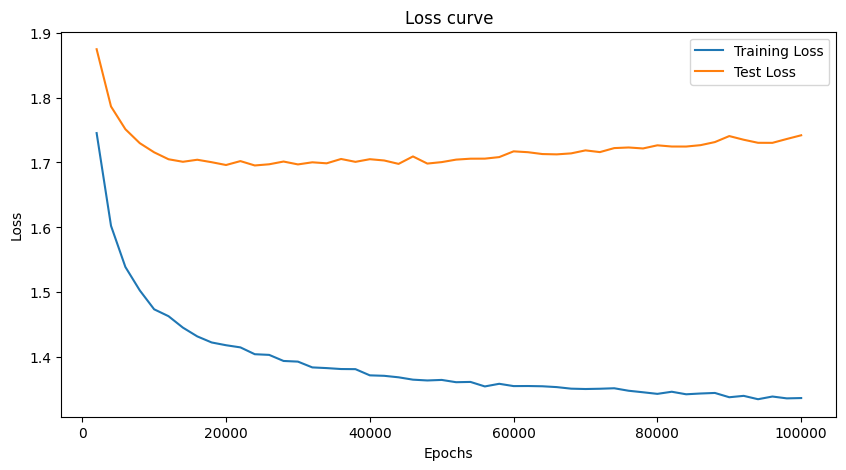

In [9]:
import matplotlib.pyplot as plt

### Visualize loss progression ###
plt.figure(figsize=(10, 5))
plt.plot(epoch_count, train_loss_values, label="Training Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")
plt.title("Loss curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [10]:
### Use model ###

def evaluate(model, start='\n', length=1000):
    model.eval()

    hidden = model.init_hidden()
    prime_input = torch.tensor([[char_to_num[c] for c in start]])
    predicted = start

    # Build up hidden state
    for i in range(len(start) - 1):
        with torch.inference_mode():
            _, hidden = model(prime_input[i].to(device), hidden)

    # Generate new sequence
    input = prime_input[-1]
    for i in range(length):
        with torch.inference_mode():
            output, hidden = model(input.to(device), hidden)

        probs = F.softmax(output.detach(), dim=1)
        ix = torch.multinomial(probs, num_samples=1)[0]

        char = num_to_char[ix.item()]
        predicted += char
        input = ix.clone().detach()
    
    return predicted
    
print(evaluate(model))



MERCUTIO:
Will hebbed along that damnar shame goodly for else such secret.

First Servant:
It wounds a gentleman's man, then
That of all the attemetresar. As I can satisf:
And but.
You mayely.
I beat a brief that you could, treamented, in humities and pity you been I protested wilk, in mighty dreamon'd him zaute to bear a slaughter, and take her things,
And this it was the time and how
Gentleman; the gods from out my worth so reas thy fellow togethers, and thunser this alunclines please a more comfort hereag and Grey: I'll never
not suffer'd, did at old acreab'st thou thride.

JULIET:
O, I am to meet
Aban, dear my fault.

WARWICK:
Sir Just of hearty:
I'll not in thy joy.

POMPEY:
Thy father's content
His, thank her read the conquerors.

PETER:
Here joyleth death?
So had traitor is appraise; and nothing dissold,
How know's rude, good murders with one tow,
I had ase the nevers of the sets to me:
More:
If then you so done
When she do your natural I,
Be him note this life my groan to the